# IDM phase-transition surrogate: region-held-out generalization

This notebook tests a stricter notion of generalization than the random train/validation/test split.

**Question:** how well does the surrogate predict phase-transition observables in a contiguous region of the sampled IDM parameter space that was completely absent from training?

The same targets, preprocessing philosophy, and three model classes are used as in the random-split benchmark:

- Linear regression
- Histogram gradient boosting
- PyTorch MLP

The held-out region is defined from the BSM input features only, using the first principal-component direction. No phase-transition targets are used to define the split.

In [ ]:
import random
import copy
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_num_threads(max(1, torch.get_num_threads() - 1))

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)
print("CPU threads:", torch.get_num_threads())

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_FILE = "../data/idm_pt.tsv"
MODELS_DIR = "../models/nb3/"
RESULTS_DIR = "../results/nb3/"

# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------

BSM_FEATURES = ["mH", "mA", "mHp", "l2", "l345"]

TARGET_COLUMNS = ["Tcrit", "Tnuc", "log_alpha", "log_beta/H"]
PHYSICAL_TARGET_COLUMNS = ["Tcrit", "Tnuc", "alpha", "beta/H"]

N_FEATURES = len(BSM_FEATURES)
N_TARGETS = len(TARGET_COLUMNS)

# ------------------------------------------------------------
# Split configuration
# ------------------------------------------------------------

REGION_TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15

# Validation fraction inside the 85% region-development sample.
VALIDATION_SIZE_INSIDE_REGION_DEV = (VALIDATION_SIZE / (1.0 - REGION_TEST_SIZE))

print("Number of input features:", N_FEATURES)
print("Number of targets:", N_TARGETS)

PyTorch version: 2.14.0+cpu
Device: cpu
CPU threads: 3
Number of input features: 5
Number of targets: 4


## 1. Load and prepare the one-step FOPT sample

In [2]:
df = pd.read_csv(DATA_FILE, sep="\t")
df_clean = df.copy()
df_clean["Tcrit"] = df_clean["Tcrit"].mask(df_clean["Tcrit"] == -999, df_clean["Tnuc"])
df_clean = df_clean[df_clean["beta/H"] != -999]
df_clean["log_alpha"] = np.log10(df_clean["alpha"])
df_clean["log_beta/H"] = np.log10(df_clean["beta/H"])

# ------------------------------------------------------------
# Select one-step FOPT sample
# ------------------------------------------------------------

df_ml = df_clean[df_clean["transition_pattern"] == 'oh1'].copy()
print(df_ml.shape)
df_ml[BSM_FEATURES + TARGET_COLUMNS].describe().T

(50297, 20)


,count,mean,std,min,25%,50%,75%,max
mH,50297.0,183.547872,50.824493,46.266962,149.840121,195.517634,226.230758,249.999661
mA,50297.0,318.390926,81.748667,46.398863,261.812989,319.986041,380.676768,499.907029
mHp,50297.0,336.232772,82.778338,70.409150,280.809764,341.964620,398.592772,530.183763
l2,50297.0,1.919572,1.097292,0.000112,0.986682,1.906370,2.840399,4.161707
l345,50297.0,1.047533,0.604068,0.000030,0.554487,1.012635,1.506306,2.713783
Tcrit,50297.0,116.654636,15.814025,71.638750,106.102871,118.417725,127.767578,156.720831
Tnuc,50297.0,113.359869,20.384383,37.885160,102.171051,117.314253,127.552613,156.713495
log_alpha,50297.0,-2.379646,0.730958,-4.317576,-2.814510,-2.296829,-1.894980,-0.146363
log_beta/H,50297.0,4.515161,1.016236,0.666147,3.765377,4.432380,5.266219,13.749588


## 2. Define the held-out parameter-space region

We use the five BSM parameters only to define a one-dimensional geometric coordinate.

The inputs are standardized, then PCA is fitted to the BSM feature space. The highest 15% of points along the first principal-component coordinate are designated as the held-out region.

This split is deterministic for `SEED = 42` and uses no transition observables or ML targets.

In [ ]:
# ============================================================
# 2. Define a physically explicit region-held-out test set
# ============================================================

HELDOUT_FEATURE = "mA"
REGION_TEST_SIZE = 0.15

# ------------------------------------------------------------
# Determine the threshold corresponding to the highest 15%
# of the chosen BSM parameter.
# ------------------------------------------------------------

holdout_threshold = df_ml[HELDOUT_FEATURE].quantile(1.0 - REGION_TEST_SIZE)

region_test_df = df_ml[df_ml[HELDOUT_FEATURE] >= holdout_threshold].copy()

region_dev_df = df_ml[df_ml[HELDOUT_FEATURE] < holdout_threshold].copy()

print("Held-out feature:", HELDOUT_FEATURE)
print("Holdout threshold:", holdout_threshold)

print("\nFull dataset:         ", df_ml.shape)
print("Region development:   ", region_dev_df.shape)
print("Held-out region test: ", region_test_df.shape)

print("\nFractions:")
print("Development:", len(region_dev_df) / len(df_ml))

print("Held-out test:", len(region_test_df) / len(df_ml))

Held-out feature: mA
Holdout threshold: 408.18505139999996

Full dataset:          (50297, 20)
Region development:    (42752, 20)
Held-out region test:  (7545, 20)

Fractions:
Development: 0.8499910531443228
Held-out test: 0.15000894685567728


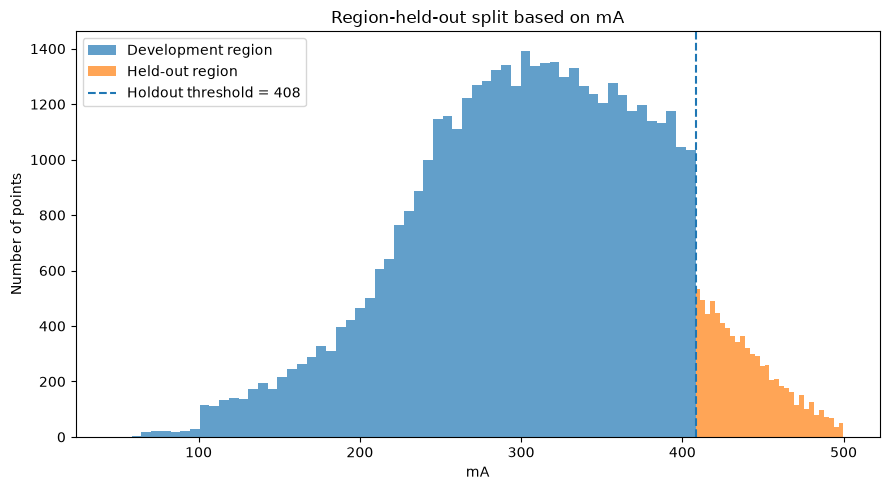

In [4]:
# ============================================================
# 3. Visualize the held-out region
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    region_dev_df[HELDOUT_FEATURE],
    bins=60,
    alpha=0.7,
    label="Development region",
)

plt.hist(
    region_test_df[HELDOUT_FEATURE],
    bins=30,
    alpha=0.7,
    label="Held-out region",
)

plt.axvline(
    holdout_threshold,
    linestyle="--",
    label=f"Holdout threshold = {holdout_threshold:.3g}",
)

plt.xlabel(HELDOUT_FEATURE)
plt.ylabel("Number of points")
plt.title(
    f"Region-held-out split based on {HELDOUT_FEATURE}"
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4. Compare BSM parameter distributions
# ============================================================

region_summary = pd.concat(
    {
        "Development": region_dev_df[BSM_FEATURES].describe().T[["min", "25%", "50%", "75%", "max"]],
        "Held-out test": region_test_df[BSM_FEATURES].describe().T[["min", "25%", "50%", "75%", "max"]],
    },
    axis=1,
)

region_summary

Development                                                  \
             min         25%         50%         75%         max   
mH     46.266962  142.729681  189.943292  222.984020  249.999661   
mA     46.398863  251.818748  303.076609  352.518345  408.172491   
mHp    70.409150  269.253799  325.434949  372.121395  453.027756   
l2      0.000112    1.009218    1.927715    2.864630    4.161707   
l345    0.000047    0.653134    1.119547    1.580706    2.713783   

     Held-out test                                                  
               min         25%         50%         75%         max  
mH       57.449653  189.842383  218.404241  236.528171  249.992127  
mA      408.193425  419.925746  434.411388  453.497509  499.907029  
mHp     398.087760  432.171972  449.315413  467.855609  530.183763  
l2        0.000434    0.860714    1.786535    2.714656    3.876122  
l345      0.000030    0.225831    0.495829    0.856919    2.207097

## 3. Train/validation split inside the development region

The held-out region remains untouched.

The remaining 85% is split into approximately:

- 70% training
- 15% validation

In [6]:
# ============================================================
# 5. Development / validation split
# ============================================================

region_train_df, region_validation_df = train_test_split(
    region_dev_df,
    test_size=VALIDATION_SIZE_INSIDE_REGION_DEV,
    random_state=SEED,
)

print("Region training:      ", region_train_df.shape)
print("Region validation:    ", region_validation_df.shape)
print("Held-out region test: ", region_test_df.shape)

print("Fractions of full ML sample:")
print("Training:   ", len(region_train_df) / len(df_ml))
print("Validation: ", len(region_validation_df) / len(df_ml))
print("Test:       ", len(region_test_df) / len(df_ml))

Region training:       (35207, 20)
Region validation:     (7545, 20)
Held-out region test:  (7545, 20)
Fractions of full ML sample:
Training:    0.6999821062886454
Validation:  0.15000894685567728
Test:        0.15000894685567728


## 4. Prepare arrays and preprocessing

In [7]:
# ============================================================
# 6. Prepare ML arrays
# ============================================================

X_region_train = region_train_df[BSM_FEATURES].to_numpy(dtype=np.float32)
X_region_validation = region_validation_df[BSM_FEATURES].to_numpy(dtype=np.float32)
X_region_test = region_test_df[BSM_FEATURES].to_numpy(dtype=np.float32)

y_region_train = region_train_df[TARGET_COLUMNS].to_numpy(dtype=np.float32)
y_region_validation = region_validation_df[TARGET_COLUMNS].to_numpy(dtype=np.float32)
y_region_test = region_test_df[TARGET_COLUMNS].to_numpy(dtype=np.float32)

print("X_region_train:", X_region_train.shape)
print("y_region_train:", y_region_train.shape)

print("X_region_validation:", X_region_validation.shape)
print("y_region_validation:", y_region_validation.shape)

print("X_region_test:", X_region_test.shape)
print("y_region_test:", y_region_test.shape)

X_region_train: (35207, 5)
y_region_train: (35207, 4)
X_region_validation: (7545, 5)
y_region_validation: (7545, 4)
X_region_test: (7545, 5)
y_region_test: (7545, 4)


In [ ]:
# ============================================================
# 7. Standardize BSM features
# ============================================================

# IMPORTANT:
# This scaler is fitted on the training subset only.
region_feature_scaler = StandardScaler()

X_region_train_scaled = (region_feature_scaler.fit_transform(X_region_train))

X_region_validation_scaled = (region_feature_scaler.transform(X_region_validation))

X_region_test_scaled = (region_feature_scaler.transform(X_region_test))

In [ ]:
# ============================================================
# 8. Evaluation utilities
# ============================================================

def evaluate_predictions(y_true, y_pred, target_names):
    rows = []

    for i, target in enumerate(target_names):

        rmse = root_mean_squared_error(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2 = r2_score(y_true[:, i], y_pred[:, i])

        rows.append({
            "target": target,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
        })

    return pd.DataFrame(rows)


def to_physical_targets(y_transformed):

    result = np.empty_like(y_transformed)

    result[:, 0] = y_transformed[:, 0]
    result[:, 1] = y_transformed[:, 1]
    result[:, 2] = 10 ** y_transformed[:, 2]
    result[:, 3] = 10 ** y_transformed[:, 3]

    return result


def plot_predictions(y_true, y_pred, target_names, model_name):

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    for ax, i in zip(axes.ravel(), range(len(target_names))):

        ax.scatter(y_true[:, i], y_pred[:, i], s=8, alpha=0.35)

        minimum = min(y_true[:, i].min(), y_pred[:, i].min())
        maximum = max(y_true[:, i].max(), y_pred[:, i].max())

        ax.plot([minimum, maximum], [minimum, maximum], linestyle="--")

        ax.set_xlabel(f"True {target_names[i]}")
        ax.set_ylabel(f"Predicted {target_names[i]}")

        ax.set_title(f"{model_name}: {target_names[i]}")

    plt.tight_layout()
    plt.show()

## 5. Linear regression baseline

In [ ]:
# ============================================================
# 9. Linear regression
# ============================================================

region_linear_model = LinearRegression()

region_linear_model.fit(X_region_train_scaled, y_region_train)

region_linear_validation_pred = region_linear_model.predict(X_region_validation_scaled)
region_linear_test_pred = region_linear_model.predict(X_region_test_scaled)

region_linear_validation_results = evaluate_predictions(
    y_region_validation,
    region_linear_validation_pred,
    TARGET_COLUMNS,
)

region_linear_test_results = evaluate_predictions(
    y_region_test,
    region_linear_test_pred,
    TARGET_COLUMNS,
)

region_linear_validation_results

,target,RMSE,MAE,R2
0,Tcrit,3.808200,2.968660,0.917310
1,Tnuc,5.514508,4.128948,0.884064
2,log_alpha,0.215950,0.165525,0.897068
3,log_beta/H,0.360322,0.265122,0.857666


## 6. Histogram gradient boosting

In [ ]:
# ============================================================
# 10. Gradient boosting
# ============================================================

region_gradient_base = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    early_stopping=False,
    random_state=SEED,
)

region_gradient_model = MultiOutputRegressor(region_gradient_base, n_jobs=-2)

region_gradient_model.fit(X_region_train, y_region_train)

region_gradient_validation_pred = region_gradient_model.predict(X_region_validation)
region_gradient_test_pred = region_gradient_model.predict(X_region_test)

region_gradient_validation_results = evaluate_predictions(
    y_region_validation,
    region_gradient_validation_pred,
    TARGET_COLUMNS,
)

region_gradient_test_results = evaluate_predictions(
    y_region_test,
    region_gradient_test_pred,
    TARGET_COLUMNS,
)

region_gradient_validation_results

,target,RMSE,MAE,R2
0,Tcrit,1.136138,0.864187,0.992640
1,Tnuc,1.720117,1.201955,0.988720
2,log_alpha,0.093561,0.071783,0.980679
3,log_beta/H,0.174273,0.105791,0.966704


## 7. Neural network

In [ ]:
# ============================================================
# 11. Scale targets
# ============================================================

region_target_scaler = StandardScaler()

y_region_train_scaled = region_target_scaler.fit_transform(y_region_train)
y_region_validation_scaled = region_target_scaler.transform(y_region_validation)
y_region_test_scaled = region_target_scaler.transform(y_region_test)

In [13]:
# ============================================================
# 12. Define neural network
# ============================================================

class PTRegressor(nn.Module):

    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_inputs, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, n_outputs),
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
# ============================================================
# 13. PyTorch tensors
# ============================================================

X_region_train_tensor = torch.tensor(X_region_train_scaled, dtype=torch.float32)
y_region_train_tensor = torch.tensor(y_region_train_scaled, dtype=torch.float32)

X_region_validation_tensor = torch.tensor(X_region_validation_scaled, dtype=torch.float32)
y_region_validation_tensor = torch.tensor(y_region_validation_scaled, dtype=torch.float32)

X_region_test_tensor = torch.tensor(X_region_test_scaled, dtype=torch.float32)
y_region_test_tensor = torch.tensor(y_region_test_scaled, dtype=torch.float32)

In [15]:
# ============================================================
# 14. Train neural network
# ============================================================

def train_mlp_model(
    X_train_tensor,
    y_train_tensor,
    X_validation_tensor,
    y_validation_tensor,
    n_inputs,
    n_outputs,
    seed=SEED,
    max_epochs=300,
    patience=25,
    batch_size=512,
):

    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    model = PTRegressor(
        n_inputs=n_inputs,
        n_outputs=n_outputs,
    ).to(DEVICE)

    loss_function = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-5,
    )

    best_validation_loss = np.inf
    best_state = None
    epochs_without_improvement = 0

    training_history = []

    for epoch in range(1, max_epochs + 1):

        model.train()

        batch_losses = []

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            prediction = model(X_batch)

            loss = loss_function(
                prediction,
                y_batch,
            )

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        mean_train_loss = np.mean(batch_losses)

        model.eval()

        with torch.no_grad():

            validation_prediction = model(
                X_validation_tensor.to(DEVICE)
            )

            validation_loss = loss_function(
                validation_prediction,
                y_validation_tensor.to(DEVICE),
            ).item()

        training_history.append({
            "epoch": epoch,
            "train_loss": mean_train_loss,
            "validation_loss": validation_loss,
        })

        if validation_loss < best_validation_loss:

            best_validation_loss = validation_loss

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if epoch == 1 or epoch % 10 == 0:

            print(
                f"Epoch {epoch:3d} | "
                f"train MSE = {mean_train_loss:.6f} | "
                f"validation MSE = {validation_loss:.6f}"
            )

        if epochs_without_improvement >= patience:

            print(
                f"\nEarly stopping at epoch {epoch}"
            )
            break

    model.load_state_dict(best_state)

    return (
        model,
        pd.DataFrame(training_history),
    )


region_mlp_model, region_mlp_history = train_mlp_model(
    X_region_train_tensor,
    y_region_train_tensor,
    X_region_validation_tensor,
    y_region_validation_tensor,
    n_inputs=N_FEATURES,
    n_outputs=N_TARGETS,
)

Epoch   1 | train MSE = 0.493524 | validation MSE = 0.082702
Epoch  10 | train MSE = 0.005072 | validation MSE = 0.007806
Epoch  20 | train MSE = 0.002373 | validation MSE = 0.005898
Epoch  30 | train MSE = 0.001818 | validation MSE = 0.005350
Epoch  40 | train MSE = 0.001570 | validation MSE = 0.005232
Epoch  50 | train MSE = 0.001400 | validation MSE = 0.005126
Epoch  60 | train MSE = 0.001288 | validation MSE = 0.005118
Epoch  70 | train MSE = 0.001233 | validation MSE = 0.005105
Epoch  80 | train MSE = 0.001174 | validation MSE = 0.004848
Epoch  90 | train MSE = 0.001146 | validation MSE = 0.005004
Epoch 100 | train MSE = 0.001068 | validation MSE = 0.004922
Epoch 110 | train MSE = 0.001043 | validation MSE = 0.004954
Epoch 120 | train MSE = 0.001038 | validation MSE = 0.004976

Early stopping at epoch 127


In [ ]:
# ============================================================
# 15. Neural-network predictions
# ============================================================

region_mlp_model.eval()

with torch.no_grad():

    region_mlp_validation_scaled = region_mlp_model(X_region_validation_tensor.to(DEVICE)).cpu().numpy()
    region_mlp_test_scaled = region_mlp_model(X_region_test_tensor.to(DEVICE)).cpu().numpy()

region_mlp_validation_pred = region_target_scaler.inverse_transform(region_mlp_validation_scaled)
region_mlp_test_pred = region_target_scaler.inverse_transform(region_mlp_test_scaled)

region_mlp_validation_results = evaluate_predictions(
    y_region_validation,
    region_mlp_validation_pred,
    TARGET_COLUMNS,
)

region_mlp_test_results = evaluate_predictions(
    y_region_test,
    region_mlp_test_pred,
    TARGET_COLUMNS,
)

region_mlp_validation_results

,target,RMSE,MAE,R2
0,Tcrit,0.388523,0.156132,0.999139
1,Tnuc,0.373346,0.222714,0.999469
2,log_alpha,0.016681,0.011371,0.999386
3,log_beta/H,0.124964,0.023007,0.982880


In [ ]:
# ============================================================
# 16. Region-held-out validation comparison
# ============================================================

region_validation_predictions = {
    "Linear regression":
        region_linear_validation_pred,

    "Gradient boosting":
        region_gradient_validation_pred,

    "Neural network":
        region_mlp_validation_pred,
}

region_validation_results = []

for model_name, predictions in region_validation_predictions.items():

    result = evaluate_predictions(
        y_region_validation,
        predictions,
        TARGET_COLUMNS,
    )

    result.insert(0, "model", model_name)

    region_validation_results.append(result)

region_validation_comparison = pd.concat(
    region_validation_results,
    ignore_index=True,
)

region_validation_comparison

,model,target,RMSE,MAE,R2
0,Linear regression,Tcrit,3.808200,2.968660,0.917310
1,Linear regression,Tnuc,5.514508,4.128948,0.884064
2,Linear regression,log_alpha,0.215950,0.165525,0.897068
3,Linear regression,log_beta/H,0.360322,0.265122,0.857666
4,Gradient boosting,Tcrit,1.136138,0.864187,0.992640
5,Gradient boosting,Tnuc,1.720117,1.201955,0.988720
6,Gradient boosting,log_alpha,0.093561,0.071783,0.980679
7,Gradient boosting,log_beta/H,0.174273,0.105791,0.966704
8,Neural network,Tcrit,0.388523,0.156132,0.999139
9,Neural network,Tnuc,0.373346,0.222714,0.999469


## 8. Held-out-region test performance

This is the key result of the notebook: the model is evaluated only after all training, target scaling, and feature scaling have been fitted without the held-out region.

In [ ]:
# ============================================================
# 17. Region-held-out test comparison
# ============================================================

region_test_predictions = {
    "Linear regression":
        region_linear_test_pred,

    "Gradient boosting":
        region_gradient_test_pred,

    "Neural network":
        region_mlp_test_pred,
}

region_test_results = []

for model_name, predictions in region_test_predictions.items():

    result = evaluate_predictions(
        y_region_test,
        predictions,
        TARGET_COLUMNS,
    )

    result.insert(0, "model", model_name)

    region_test_results.append(result)

region_test_comparison = pd.concat(
    region_test_results,
    ignore_index=True,
)

region_test_comparison

,model,target,RMSE,MAE,R2
0,Linear regression,Tcrit,12.108139,10.288623,-0.182979
1,Linear regression,Tnuc,19.833912,16.568422,-0.119194
2,Linear regression,log_alpha,0.384051,0.303823,0.368519
3,Linear regression,log_beta/H,0.657355,0.547603,0.063518
4,Gradient boosting,Tcrit,13.115191,9.526913,-0.387942
5,Gradient boosting,Tnuc,19.990597,14.270441,-0.136947
6,Gradient boosting,log_alpha,0.513296,0.372062,-0.128022
7,Gradient boosting,log_beta/H,0.730299,0.536594,-0.155848
8,Neural network,Tcrit,2.187726,1.376033,0.961380
9,Neural network,Tnuc,5.395662,3.098841,0.917172


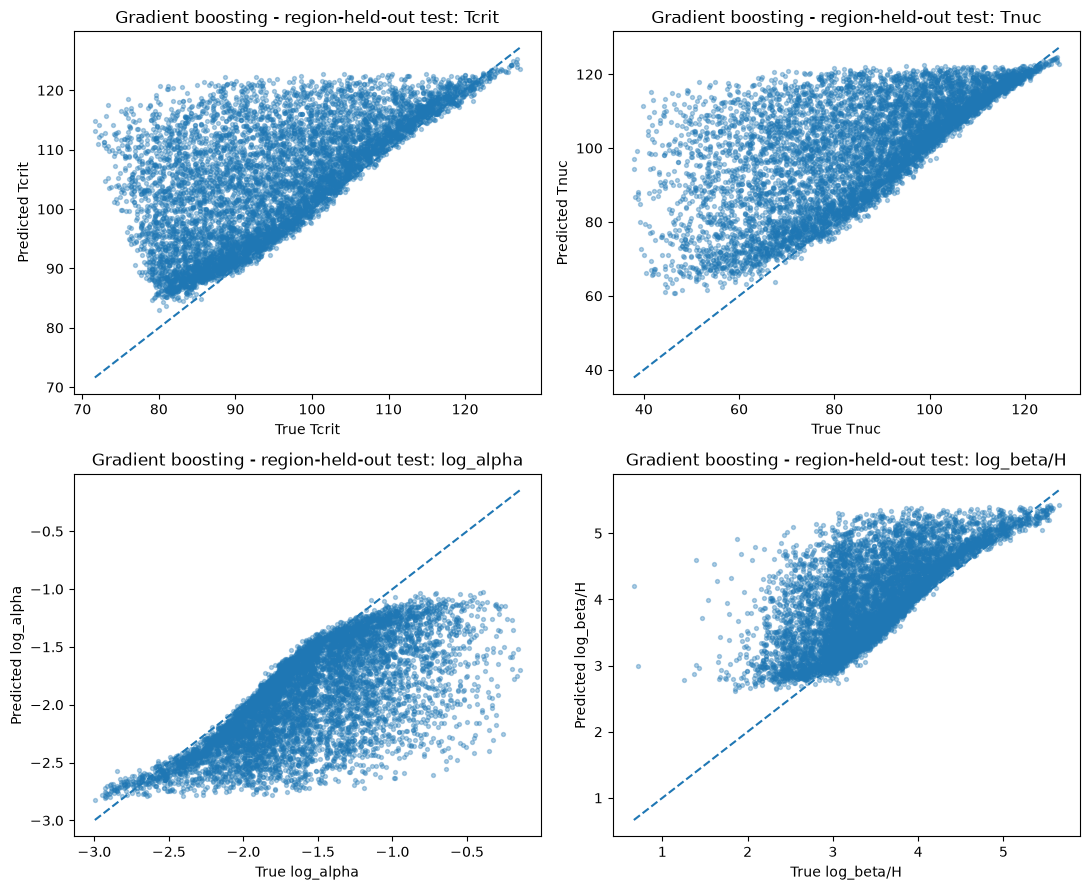

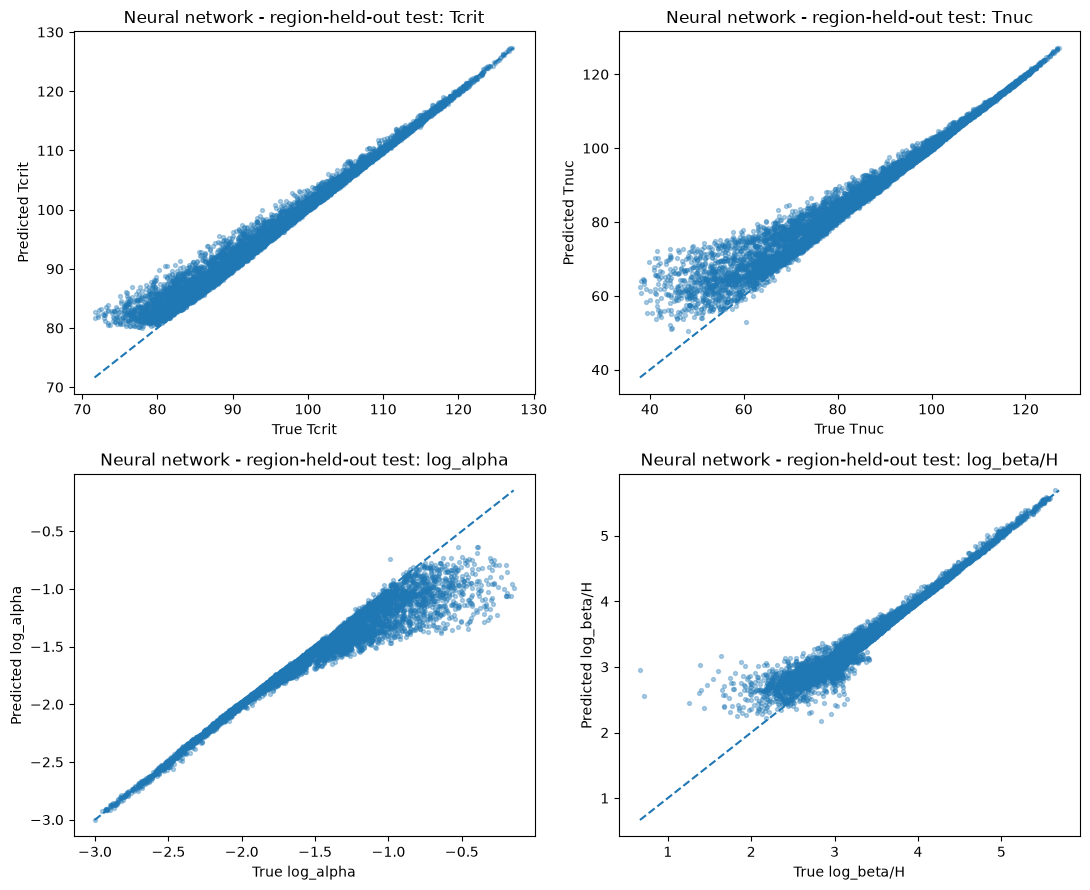

In [19]:
# ============================================================
# 18. Prediction plots in held-out region
# ============================================================

plot_predictions(
    y_region_test,
    region_gradient_test_pred,
    TARGET_COLUMNS,
    "Gradient boosting - region-held-out test",
)

plot_predictions(
    y_region_test,
    region_mlp_test_pred,
    TARGET_COLUMNS,
    "Neural network - region-held-out test",
)

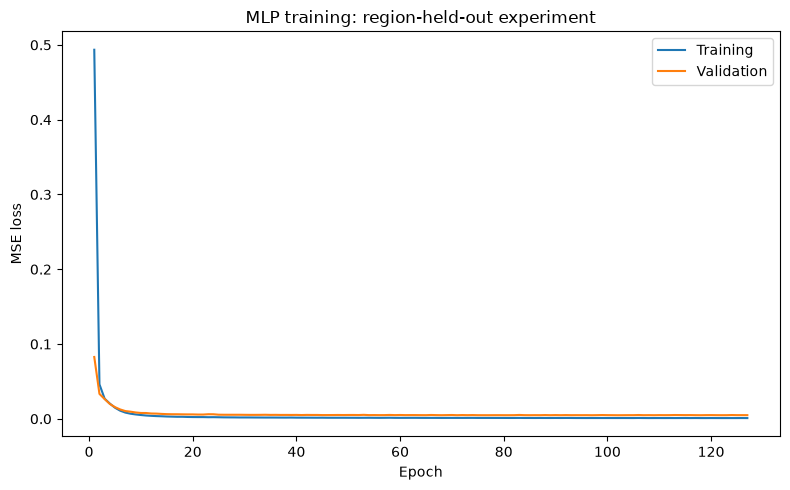

In [20]:
# ============================================================
# 19. MLP training history
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    region_mlp_history["epoch"],
    region_mlp_history["train_loss"],
    label="Training",
)

plt.plot(
    region_mlp_history["epoch"],
    region_mlp_history["validation_loss"],
    label="Validation",
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("MLP training: region-held-out experiment")
plt.legend()

plt.tight_layout()
plt.show()

## 9. Compare with the original random-split experiment

The notebook 2 saves `test_results.tsv`. This notebook can read that file directly, so it does not depend on variables from notebook 2.

The comparison is deliberately descriptive: random-split performance measures interpolation-like generalization within the sampled cloud, while this notebook measures performance in a contiguous region held out during training.

In [ ]:
# ============================================================
# 20. Compare random-split and region-held-out test results
# ============================================================

random_test_file = RESULTS_DIR + "test_results.tsv"

random_test_comparison = pd.read_csv(random_test_file, sep="\t")

random_test_comparison.insert(0, "split", "Random test")

region_test_comparison_labeled = region_test_comparison.copy()

region_test_comparison_labeled.insert(0, "split", "Region-held-out test")

generalization_comparison = pd.concat(
    [
        random_test_comparison,
        region_test_comparison_labeled,
    ],
    ignore_index=True,
)

generalization_comparison

,split,model,target,RMSE,MAE,R2
0,Random test,Linear regression,Tcrit,5.009631,3.906038,0.897891
1,Random test,Linear regression,Tnuc,8.022371,6.001245,0.843860
2,Random test,Linear regression,log_alpha,0.234527,0.174649,0.895472
3,Random test,Linear regression,log_beta/H,0.373204,0.281049,0.862889
4,Random test,Gradient boosting,Tcrit,1.239068,0.965290,0.993753
5,Random test,Gradient boosting,Tnuc,2.227798,1.473282,0.987959
6,Random test,Gradient boosting,log_alpha,0.105883,0.079763,0.978694
7,Random test,Gradient boosting,log_beta/H,0.151511,0.111664,0.977402
8,Random test,Neural network,Tcrit,0.208330,0.152268,0.999823
9,Random test,Neural network,Tnuc,0.448019,0.238228,0.999513


In [22]:
# ============================================================
# 21. Explicit performance degradation
# ============================================================

random_nn = (
    random_test_comparison[
        random_test_comparison["model"] == "Neural network"
    ]
    .set_index("target")
)

region_nn = (
    region_test_comparison[
        region_test_comparison["model"] == "Neural network"
    ]
    .set_index("target")
)

nn_degradation = pd.DataFrame({
    "random_RMSE": random_nn["RMSE"],
    "region_RMSE": region_nn["RMSE"],
    "RMSE_ratio_region_over_random": (
        region_nn["RMSE"] / random_nn["RMSE"]
    ),
    "random_MAE": random_nn["MAE"],
    "region_MAE": region_nn["MAE"],
    "MAE_ratio_region_over_random": (
        region_nn["MAE"] / random_nn["MAE"]
    ),
    "random_R2": random_nn["R2"],
    "region_R2": region_nn["R2"],
})

display(nn_degradation.reset_index())

,target,random_RMSE,region_RMSE,RMSE_ratio_region_over_random,random_MAE,region_MAE,MAE_ratio_region_over_random,random_R2,region_R2
0,Tcrit,0.208330,2.187726,10.501245,0.152268,1.376033,9.036918,0.999823,0.961380
1,Tnuc,0.448019,5.395662,12.043385,0.238228,3.098841,13.007869,0.999513,0.917172
2,log_alpha,0.018440,0.151381,8.209569,0.010018,0.079743,7.960308,0.999354,0.901887
3,log_beta/H,0.058076,0.163488,2.815071,0.023368,0.088594,3.791210,0.996680,0.942074


## 10. Save the experiment outputs

The models below are intentionally saved with distinct names so they cannot be confused with the models from the random-split benchmark.

In [23]:
# ============================================================
# 22. Save results
# ============================================================

region_validation_comparison.to_csv(
    RESULTS_DIR + "region_validation_results.tsv",
    sep="\t",
    index=False,
)

region_test_comparison.to_csv(
    RESULTS_DIR + "region_test_results.tsv",
    sep="\t",
    index=False,
)

generalization_comparison.to_csv(
    RESULTS_DIR + "random_vs_region_test.tsv",
    sep="\t",
    index=False,
)

nn_degradation.reset_index().to_csv(
    RESULTS_DIR + "nn_random_vs_region_degradation.tsv",
    sep="\t",
    index=False,
)

region_mlp_history.to_csv(
    RESULTS_DIR + "region_mlp_training_history.tsv",
    sep="\t",
    index=False,
)

pd.DataFrame({
    "heldout_feature": [HELDOUT_FEATURE],
    "holdout_fraction": [REGION_TEST_SIZE],
    "holdout_threshold": [holdout_threshold],
}).to_csv(
    RESULTS_DIR + "region_definition.tsv",
    sep="\t",
    index=False,
)

In [ ]:
# ============================================================
# 23. Save held-out experiment models
# ============================================================

joblib.dump(
    region_feature_scaler,
    MODELS_DIR + "region_feature_scaler.pkl",
)

joblib.dump(
    region_target_scaler,
    MODELS_DIR + "region_target_scaler.pkl",
)

joblib.dump(
    region_linear_model,
    MODELS_DIR + "region_linear_regression.pkl",
)

joblib.dump(
    region_gradient_model,
    MODELS_DIR + "region_gradient_boosting.pkl",
)

torch.save(
    region_mlp_model.state_dict(),
    MODELS_DIR + "region_mlp_regressor.pt",
)


Saved region-held-out models and results.


## Interpretation

The main quantity of interest is the change between:

- `Random test`
- `Region-held-out test`

A small degradation means the surrogate remains accurate when moving into an unseen contiguous part of the sampled parameter space.

A larger degradation indicates that the excellent random-split performance is mainly interpolation within the sampled cloud and that accuracy becomes less reliable toward the edge of the training region.

This is a more demanding and physically relevant generalization test than simply adding more model architectures.

In [25]:
print("mA threshold:", holdout_threshold)

print(
    "Development mA range:",
    region_dev_df["mA"].min(),
    "to",
    region_dev_df["mA"].max(),
)

print(
    "Held-out mA range:",
    region_test_df["mA"].min(),
    "to",
    region_test_df["mA"].max(),
)

display(region_test_comparison)
display(nn_degradation.reset_index())

mA threshold: 408.18505139999996
Development mA range: 46.398863 to 408.172491
Held-out mA range: 408.193425 to 499.907029


,model,target,RMSE,MAE,R2
0,Linear regression,Tcrit,12.108139,10.288623,-0.182979
1,Linear regression,Tnuc,19.833912,16.568422,-0.119194
2,Linear regression,log_alpha,0.384051,0.303823,0.368519
3,Linear regression,log_beta/H,0.657355,0.547603,0.063518
4,Gradient boosting,Tcrit,13.115191,9.526913,-0.387942
5,Gradient boosting,Tnuc,19.990597,14.270441,-0.136947
6,Gradient boosting,log_alpha,0.513296,0.372062,-0.128022
7,Gradient boosting,log_beta/H,0.730299,0.536594,-0.155848
8,Neural network,Tcrit,2.187726,1.376033,0.961380
9,Neural network,Tnuc,5.395662,3.098841,0.917172


,target,random_RMSE,region_RMSE,RMSE_ratio_region_over_random,random_MAE,region_MAE,MAE_ratio_region_over_random,random_R2,region_R2
0,Tcrit,0.208330,2.187726,10.501245,0.152268,1.376033,9.036918,0.999823,0.961380
1,Tnuc,0.448019,5.395662,12.043385,0.238228,3.098841,13.007869,0.999513,0.917172
2,log_alpha,0.018440,0.151381,8.209569,0.010018,0.079743,7.960308,0.999354,0.901887
3,log_beta/H,0.058076,0.163488,2.815071,0.023368,0.088594,3.791210,0.996680,0.942074
